### Clustering using scikit-learn (with pandas and matplotlib)

In [1]:
import csv
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn import cluster
from scipy.spatial.distance import cdist
from scipy.cluster.hierarchy import dendrogram, linkage
%matplotlib inline

In [2]:
import numpy as np
from google.colab import drive
drive.mount('/content/drive/')

Mounted at /content/drive/


In [3]:
ruta = '/content/drive/My Drive/MDD/Clase5 - Laboratorio'
cities = pd.read_csv('%s/Cities.csv'%ruta)
cities.head()

,city,country,latitude,longitude,temperature
0,Aalborg,Denmark,57.03,9.92,7.52
1,Aberdeen,United Kingdom,57.17,-2.08,8.10
2,Abisko,Sweden,63.35,18.83,0.20
3,Adana,Turkey,36.99,35.32,18.67
4,Albacete,Spain,39.00,-1.87,12.62


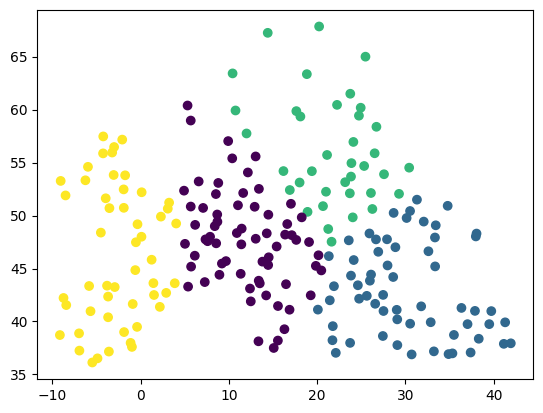

In [7]:
# K-means clustering basedo wn longitud-latitud
kmeans = cluster.KMeans(4)
kmeans.fit(cities[['longitude', 'latitude']])
labels = kmeans.labels_
plt.scatter(cities['longitude'], cities['latitude'], c=labels)
plt.show()
centroids = kmeans.cluster_centers_

In [5]:
centroids

array([[31.07839286, 43.19696429],
       [-3.00653846, 40.95769231],
       [18.31873418, 50.17227848],
       [ 3.17942308, 51.345     ]])

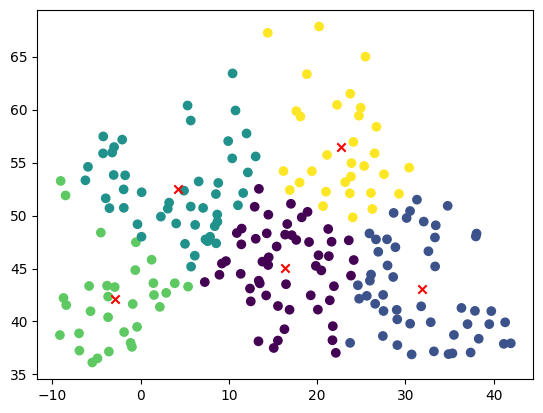

In [9]:
# Con los centroides
kmeans = cluster.KMeans(5)
kmeans.fit(cities[['longitude', 'latitude']])
labels = kmeans.labels_
centroids = kmeans.cluster_centers_
plt.scatter(cities['longitude'], cities['latitude'], c=labels)
plt.scatter(centroids[:,0], centroids[:,1], marker='x', c='red')
plt.show()

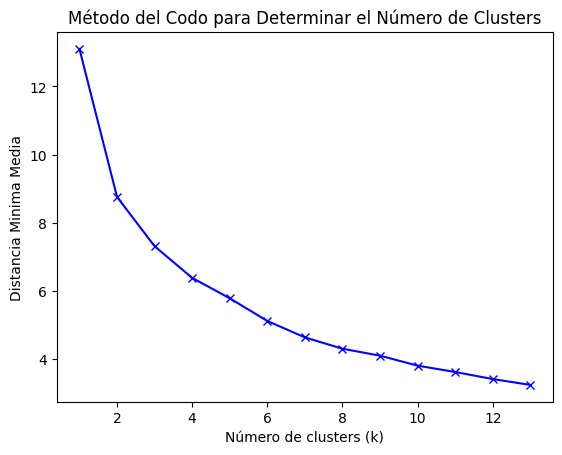

In [10]:
distortions = []
K = range(1,14)
for k in K:
    kmeanModel = cluster.KMeans(n_clusters=k).fit(cities[['longitude', 'latitude']])
    distortions.append(sum(np.min(cdist(cities[['longitude', 'latitude']], kmeanModel.cluster_centers_,
                                        'euclidean'), axis=1)) / cities[['longitude', 'latitude']].shape[0])

plt.plot(K, distortions, 'bx-')
plt.xlabel('Número de clusters (k)')
plt.ylabel('Distancia Minima Media')
plt.title('Método del Codo para Determinar el Número de Clusters')
plt.show()

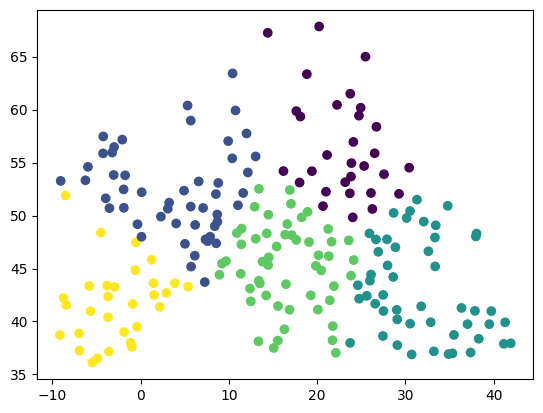

In [11]:
# K-means clustering basedo wn longitud-latitud
kmeans = cluster.KMeans(5)
kmeans.fit(cities[['longitude', 'latitude']])
labels = kmeans.labels_
plt.scatter(cities['longitude'], cities['latitude'], c=labels)
plt.show()
centroids = kmeans.cluster_centers_

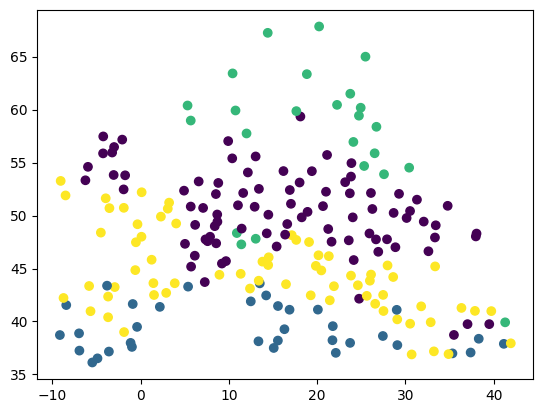

[[ 7.70390805]
 [15.55857143]
 [ 3.94541667]
 [10.65014925]]


In [12]:
# K-means clustering basado en temperatura
kmeans = cluster.KMeans(4)
kmeans.fit(cities[['temperature']])
labels = kmeans.labels_
centroids = kmeans.cluster_centers_
plt.scatter(cities['longitude'], cities['latitude'], c=labels)
plt.show()
print(centroids)

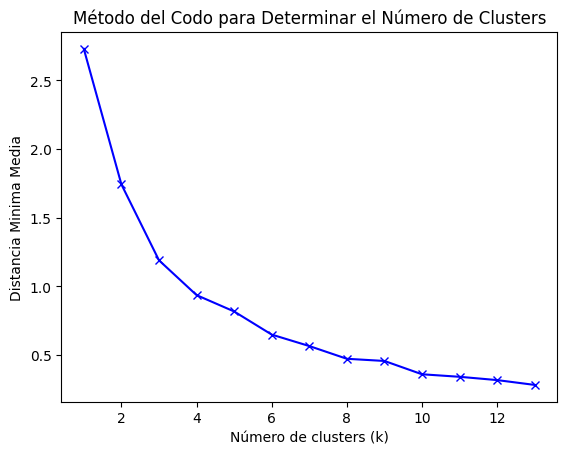

In [13]:
distortions = []
K = range(1,14)
for k in K:
    kmeanModel = cluster.KMeans(n_clusters=k).fit(cities[['temperature']])
    distortions.append(sum(np.min(cdist(cities[['temperature']], kmeanModel.cluster_centers_,
                                        'euclidean'), axis=1)) / cities[['temperature']].shape[0])

plt.plot(K, distortions, 'bx-')
plt.xlabel('Número de clusters (k)')
plt.ylabel('Distancia Minima Media')
plt.title('Método del Codo para Determinar el Número de Clusters')
plt.show()

In [14]:
df_city = cities.sample(10)
df_city

,city,country,latitude,longitude,temperature
137,Marseille,France,43.29,5.38,14.98
27,Bergen,Norway,60.39,5.32,1.75
169,Rijeka,Croatia,45.33,14.45,9.27
97,Groningen,Netherlands,53.22,6.58,8.71
191,Tampere,Finland,61.50,23.75,3.59
111,Kaunas,Lithuania,54.95,23.88,6.05
171,Rome,Italy,41.90,12.48,15.10
108,Kalamata,Greece,37.04,22.11,17.30
74,Dublin,Ireland,53.33,-6.25,8.49
28,Berlin,Germany,52.52,13.40,8.72


In [15]:
distancias = linkage(df_city[['temperature']].values, 'single')
etiquetas = df_city.city.values

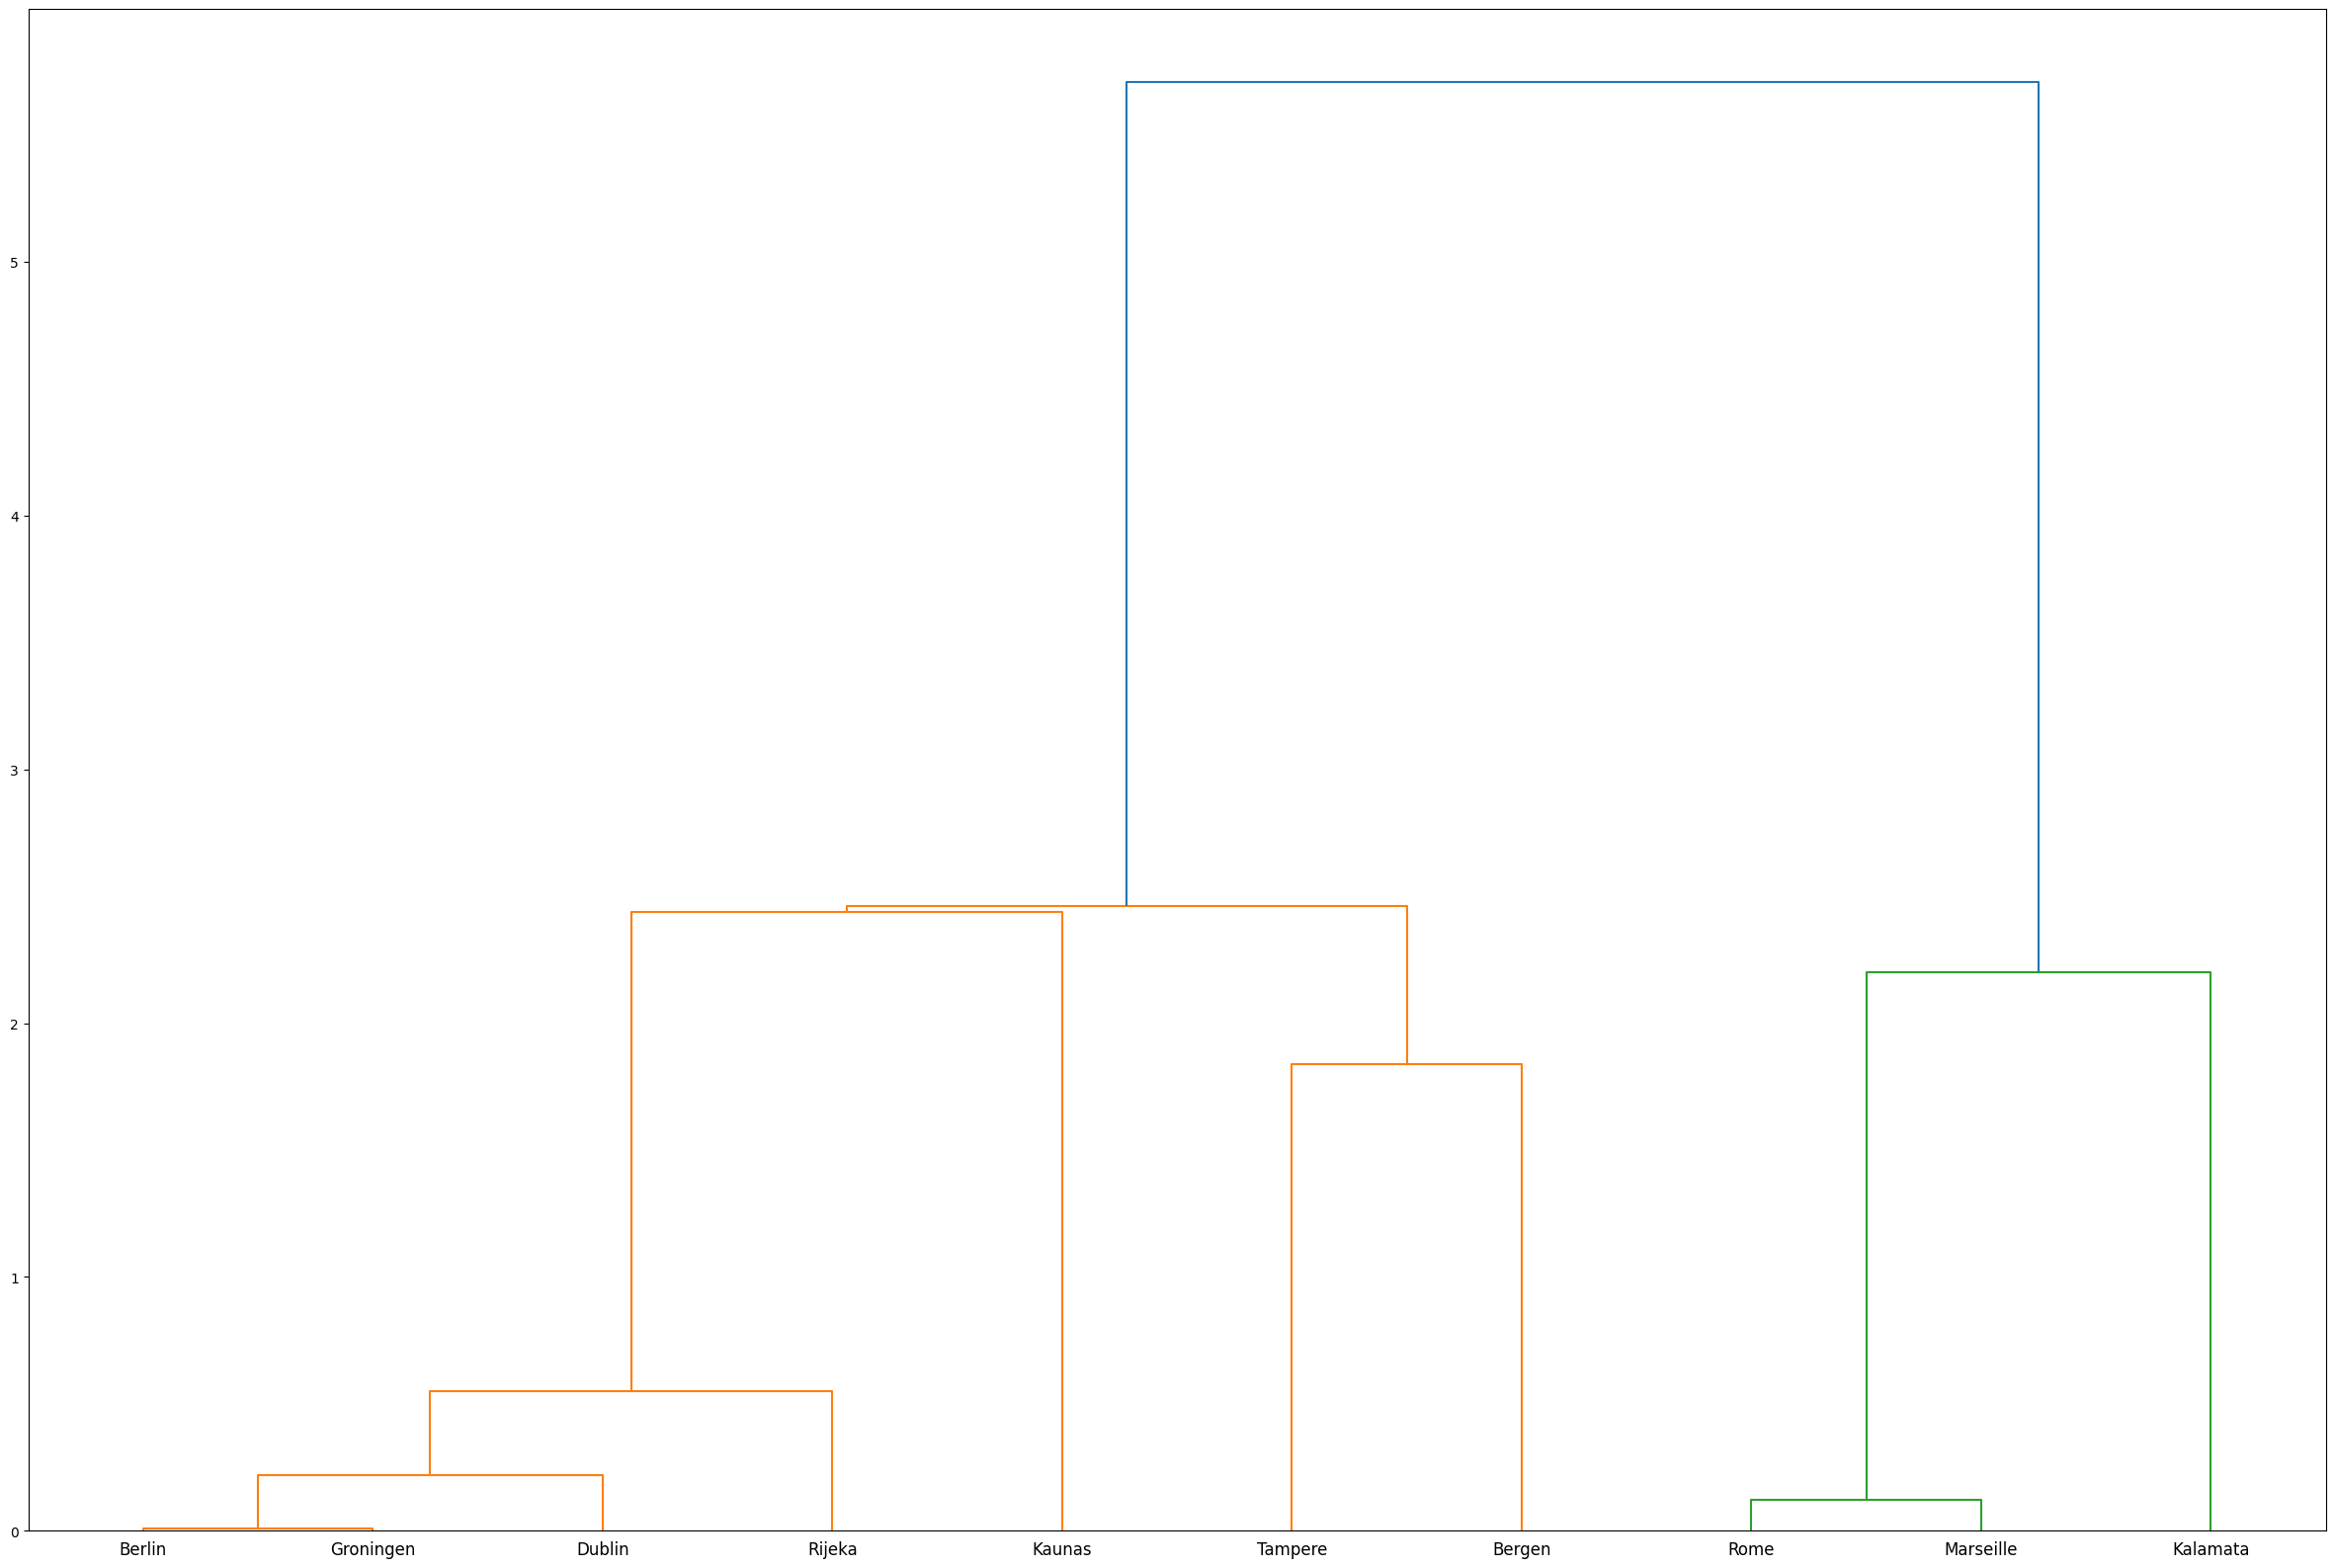

In [16]:
plt.figure(figsize=(30, 20))
dendrogram(distancias, orientation='top',labels = etiquetas, distance_sort='descending',show_leaf_counts=True)
plt.show()